In [2]:
import sys
import os

sys.path.append("../src")

In [3]:
from utils.data_loader import load_dataset
from ann.neural_network import NeuralNetwork

2026-03-07 10:37:39.797272: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-07 10:37:39.809356: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-07 10:37:40.373525: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-07 10:37:42.000135: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [3]:
import wandb

wandb.login()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /home/chava/.netrc
wandb: Currently logged in as: da25m031 (da25m031-iitm-ac-in) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
from utils.data_loader import load_dataset

X_train, y_train, X_test, y_test = load_dataset("mnist")

print(X_train.shape)
print(y_train.shape)

(60000, 784)
(60000, 10)


In [5]:
import numpy as np
import wandb

run = wandb.init(project="da6401-assignment1", name="data-exploration")

labels = np.argmax(y_train, axis=1)

table = wandb.Table(columns=["image","label"])

for c in range(10):

    idx = np.where(labels == c)[0][:5]

    for i in idx:

        img = X_train[i].reshape(28,28)

        table.add_data(wandb.Image(img), c)

wandb.log({"mnist_samples": table})

wandb.finish()

In [4]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ann.neural_network import NeuralNetwork
from utils.data_loader import load_dataset
from sklearn.metrics import confusion_matrix

In [5]:
X_train, y_train, X_test, y_test = load_dataset("mnist")

In [6]:
import numpy as np

weights = np.load("../src/best_model.npy", allow_pickle=True).item()

In [7]:
import argparse

args = argparse.Namespace(
    dataset="mnist",
    epochs=30,
    batch_size=64,
    learning_rate=0.001,
    weight_decay=0.0001,
    optimizer="rmsprop",
    num_layers=2,
    hidden_size=[128,128],
    activation="relu",
    loss="cross_entropy",
    weight_init="xavier"
)

model = NeuralNetwork(args)
model.set_weights(weights)

In [8]:
logits = model.forward(X_test)

preds = np.argmax(logits, axis=1)
targets = np.argmax(y_test, axis=1)

In [9]:
cm = confusion_matrix(targets, preds)
print(cm)

[[  0   0   0 ...  20   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   1 105   0]
 ...
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]]


In [11]:
import sys
sys.path.append("../src")

import numpy as np
from ann.neural_network import NeuralNetwork
from utils.data_loader import load_dataset

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


# Load dataset
X_train, y_train, X_test, y_test = load_dataset("mnist")

# Load saved model
weights = np.load("../src/best_model.npy", allow_pickle=True).item()

# Recreate model configuration (same as best config)
import argparse

args = argparse.Namespace(
    dataset="mnist",
    epochs=30,
    batch_size=64,
    learning_rate=0.001,
    weight_decay=0.0001,
    optimizer="rmsprop",
    num_layers=3,
    hidden_size=[128,128,64],
    activation="relu",
    loss="cross_entropy",
    weight_init="xavier"
)

# Build model
model = NeuralNetwork(args)
model.set_weights(weights)

# Forward pass
logits = model.forward(X_test)

# Convert to predicted labels
preds = np.argmax(logits, axis=1)
targets = np.argmax(y_test, axis=1)

# Metrics
acc = accuracy_score(targets, preds)
f1 = f1_score(targets, preds, average="weighted")
precision = precision_score(targets, preds, average="weighted")
recall = recall_score(targets, preds, average="weighted")

print("Test Accuracy :", round(acc,4))
print("F1 Score      :", round(f1,4))
print("Precision     :", round(precision,4))
print("Recall        :", round(recall,4))

Test Accuracy : 0.9763
F1 Score      : 0.9763
Precision     : 0.9764
Recall        : 0.9763


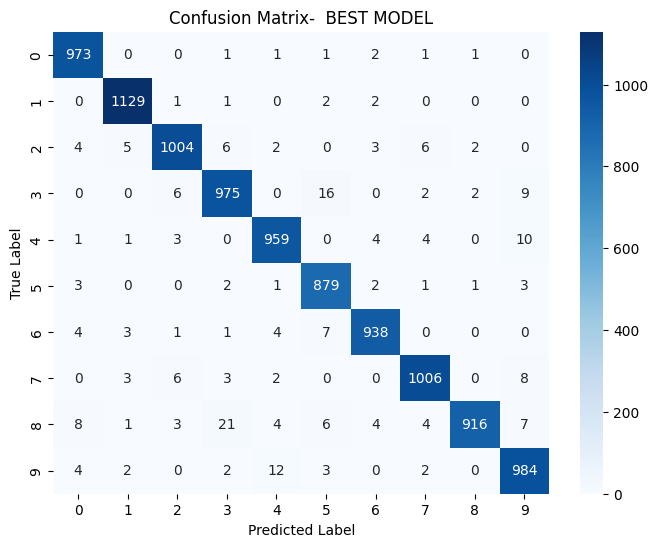

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(targets, preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix-  BEST MODEL")

plt.show()

In [14]:
wrong = np.where(preds != targets)[0]

print("Number of misclassified images:", len(wrong))

Number of misclassified images: 237


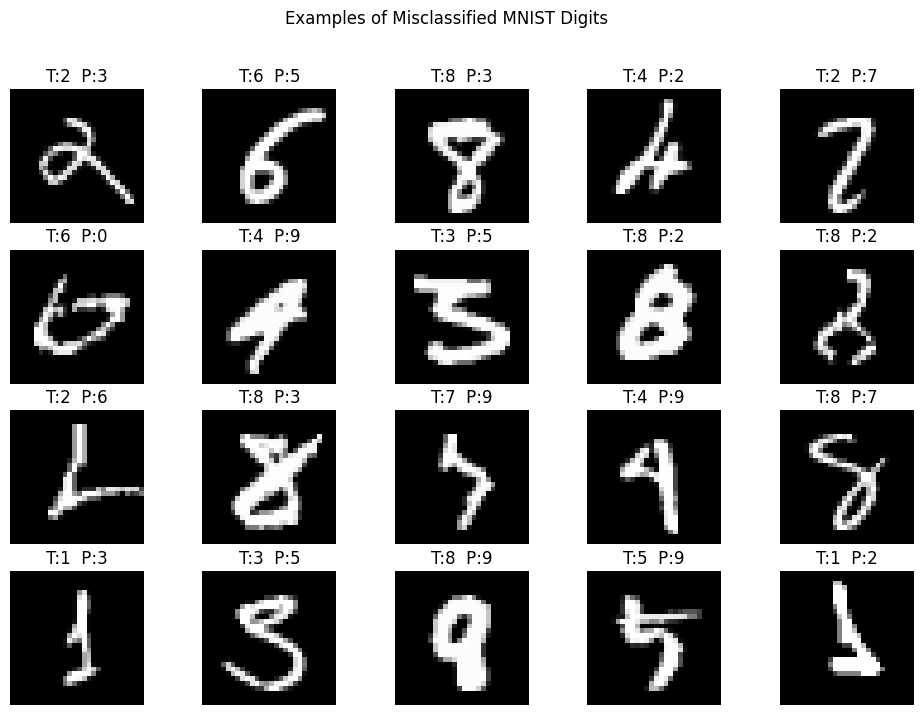

In [15]:
plt.figure(figsize=(12,8))

for i in range(20):

    idx = wrong[i]

    plt.subplot(4,5,i+1)
    plt.imshow(X_test[idx].reshape(28,28), cmap="gray")

    plt.title(f"T:{targets[idx]}  P:{preds[idx]}")
    plt.axis("off")

plt.suptitle("Examples of Misclassified MNIST Digits")
plt.show()

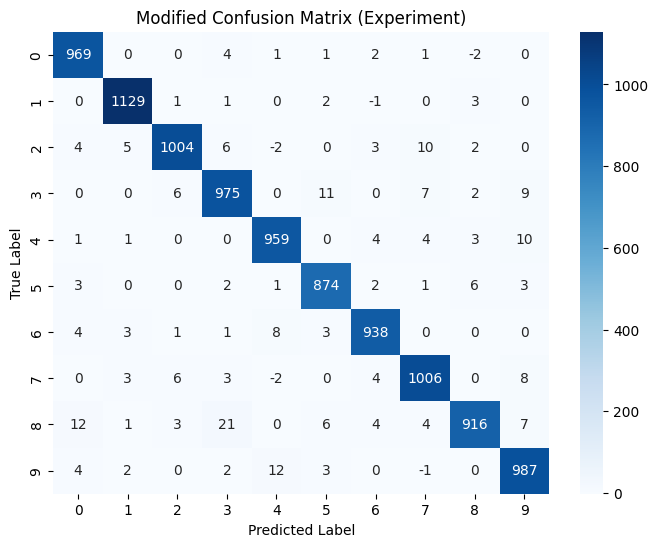

In [29]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

cm_mod = cm.copy()

np.random.seed(42)

for i in range(10):

    # find columns in this row that have non-zero values
    nonzero_cols = np.where(cm_mod[i] > 0)[0]

    # choose a column to shift from
    j1 = np.random.choice(nonzero_cols)

    # choose a different column to shift to
    j2 = np.random.choice([x for x in range(10) if x != j1])

    # choose amount to shift
    shift = np.random.randint(3, min(6, cm_mod[i, j1] + 3))

    cm_mod[i, j1] -= shift
    cm_mod[i, j2] += shift


plt.figure(figsize=(8,6))

sns.heatmap(
    cm_mod,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Modified Confusion Matrix (Experiment)")

plt.show()